In [33]:
#SETUP
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import tensorflow as tf
from pathlib import Path
from keras import applications
from keras import layers
from keras import losses
from keras import ops
from keras import optimizers
from keras import metrics
from keras import Model
from keras.applications import resnet

print("TF version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth habilitado para GPUs:", gpus)
    except Exception as e:
        print("No se pudo habilitar memory_growth:", e)
try:
    with tf.device('/GPU:0'):
        a = tf.constant([1.0, 2.0, 3.0])
        b = tf.constant([4.0, 5.0, 6.0])
        c = a + b
    print("Tensor calculado en GPU:", c)
except RuntimeError as e:
    print("Error al usar la GPU:", e)
target_shape = (192, 192)

TF version: 2.20.0
Memory growth habilitado para GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Tensor calculado en GPU: tf.Tensor([5. 7. 9.], shape=(3,), dtype=float32)


In [34]:
from pathlib import Path
import sys

# Directorio raíz (labs)
root = Path("/home/andrewyernau/dev/jupyter/labs")

parse_file = root / "parse_games_to_images.py"
if not parse_file.exists():
    raise FileNotFoundError(f"No se encontró {parse_file}")
if str(root) not in sys.path:
    sys.path.append(str(root))
from parse_games_to_images import main as parse_games


In [35]:
def pgn_to_png(pgn_subdir: str, output_subdir: str, start_move=15, end_move=23, compression=2):
    # Base dir es labs/ (un nivel arriba de notebooks/)
    base_dir = Path("..")
    parse_games(
        pgn_dir=base_dir / "dataset" / pgn_subdir,
        output_dir=base_dir / "output" / output_subdir,
        start_move=start_move,
        end_move=end_move,
        compression_factor=compression
    )


## Estilometría en Ajedrez con Redes Siamesas

Este notebook adapta una red siamesa para el análisis estilométrico de partidas de ajedrez.

**Objetivo**: Entrenar la red para reconocer el estilo de juego de Olafsson comparando:
- **Anchor**: Partidas de Olafsson (dataset/testpgns/Olafsson.pgn)
- **Positive**: Otras partidas de Olafsson (dataset/testpgnsright/Olafsson-Larsen.pgn)
- **Negative**: Partidas de otros jugadores (Howell, Saldano, Zhigalko, etc.)

La red aprenderá a identificar patrones característicos del estilo de Olafsson.

In [ ]:
pgn_to_png("testpgns", "left")
pgn_to_png("testpgnsright", "right")

## Organización de datos para Estilometría

Para entrenar la red siamesa en estilometría de ajedrez, necesitamos:
- **Anchor**: Partidas de Olafsson (del directorio left)
- **Positive**: Otras partidas de Olafsson (del directorio right)
- **Negative**: Partidas de otros jugadores (Howell, Saldano, Zhigalko, etc.)

In [36]:
cache_dir = Path(Path.home()) / "dev" / "jupyter" / "labs" / "output"
print (f"Cache dir: {cache_dir.resolve()}")
left_images_path = cache_dir / "left"
right_images_path = cache_dir / "right"
print (f"Left dir: {left_images_path.resolve()}")
print (f"Right dir: {right_images_path.resolve()}")

Cache dir: /home/andrewyernau/dev/jupyter/labs/output
Left dir: /home/andrewyernau/dev/jupyter/labs/output/left
Right dir: /home/andrewyernau/dev/jupyter/labs/output/right


In [37]:
# Separar imágenes de Olafsson de otros jugadores
all_left_images = sorted([f for f in os.listdir(left_images_path) if f.endswith('.png')])
all_right_images = sorted([f for f in os.listdir(right_images_path) if f.endswith('.png')])

# Imágenes de Olafsson del directorio left (anchor)
olafsson_left = [str(left_images_path / f) for f in all_left_images if f.startswith('Olafsson_')]

# Imágenes de Olafsson del directorio right (positive - partidas contra Larsen)
olafsson_right = [str(right_images_path / f) for f in all_right_images if 'Olafsson' in f]

# Imágenes de otros jugadores (negative)
other_players = [str(left_images_path / f) for f in all_left_images 
                 if not f.startswith('Olafsson_') and f.endswith('.png')]

print(f"Imágenes de Olafsson (anchor): {len(olafsson_left)}")
print(f"Imágenes de Olafsson (positive): {len(olafsson_right)}")
print(f"Imágenes de otros jugadores (negative): {len(other_players)}")
print(f"\nEjemplos de jugadores en negative:")
players_set = set([Path(p).stem.split('_')[0] for p in other_players])
print(f"  {', '.join(sorted(players_set))}")

Imágenes de Olafsson (anchor): 13
Imágenes de Olafsson (positive): 8
Imágenes de otros jugadores (negative): 101

Ejemplos de jugadores en negative:
  Antunesl, Howell, Izsak, Kantsler, Magem, Moroz, Narciso, Saldano, Zhigalko


In [38]:
def preprocess_image(filename, img_shape=(192, 192)):
    """
    Load the specified file as a PNG image, preprocess it and
    resize it to the target shape.
    """

    image_string = tf.io.read_file(filename)
    image = tf.image.decode_png(image_string, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, img_shape)
    return image


def preprocess_triplets(anchor, positive, negative):
    """
    Given the filenames corresponding to the three images, load and
    preprocess them.
    """

    return (
        preprocess_image(anchor),
        preprocess_image(positive),
        preprocess_image(negative),
    )



In [39]:
import numpy as np

In [40]:
# Crear datasets para estilometría de ajedrez
# Necesitamos asegurarnos de tener suficientes ejemplos positivos
# Si tenemos menos positivos, los repetimos
num_anchors = len(olafsson_left)
num_positives = len(olafsson_right)

# Validar que tenemos datos
if num_anchors == 0:
    raise ValueError("No se encontraron partidas de Olafsson en el directorio left")
if num_positives == 0:
    raise ValueError("No se encontraron partidas de Olafsson en el directorio right")
if len(other_players) == 0:
    raise ValueError("No se encontraron partidas de otros jugadores")

# Repetir positivos si es necesario para igualar el número de anchors
if num_positives < num_anchors:
    positive_images_repeated = olafsson_right * (num_anchors // num_positives + 1)
    positive_images_repeated = positive_images_repeated[:num_anchors]
else:
    positive_images_repeated = olafsson_right[:num_anchors]

# Mezclar para evitar patrones
rng = np.random.RandomState(seed=42)
rng.shuffle(positive_images_repeated)

# Crear dataset de negatives: mezclar todos los jugadores excepto Olafsson
negative_images = other_players.copy()
np.random.RandomState(seed=32).shuffle(negative_images)

# Repetir negativos para tener suficientes ejemplos
if len(negative_images) < num_anchors:
    negative_images_repeated = negative_images * (num_anchors // len(negative_images) + 1)
    negative_images_repeated = negative_images_repeated[:num_anchors]
else:
    negative_images_repeated = negative_images[:num_anchors]

print(f"\nDataset preparado:")
print(f"  Anchors (Olafsson): {len(olafsson_left)}")
print(f"  Positives (Olafsson): {len(positive_images_repeated)}")
print(f"  Negatives (Otros): {len(negative_images_repeated)}")

# Crear datasets de TensorFlow
anchor_dataset = tf.data.Dataset.from_tensor_slices(olafsson_left)
positive_dataset = tf.data.Dataset.from_tensor_slices(positive_images_repeated)
negative_dataset = tf.data.Dataset.from_tensor_slices(negative_images_repeated)

# Combinar en triplets
dataset = tf.data.Dataset.zip((anchor_dataset, positive_dataset, negative_dataset))
dataset = dataset.shuffle(buffer_size=1024)
dataset = dataset.map(preprocess_triplets, num_parallel_calls=1)

# Dividir en train y validation (80/20)
train_size = int(num_anchors * 0.8)
if train_size == 0:
    train_size = 1
    
train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size)

train_dataset = train_dataset.batch(8, drop_remainder=False)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

val_dataset = val_dataset.batch(8, drop_remainder=False)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

print(f"\nDatasets creados:")
print(f"  Train samples: {train_size}")
print(f"  Validation samples: {num_anchors - train_size}")
print(f"\n NOTA: Con solo {num_anchors} ejemplos, el modelo puede no aprender bien.")
print(f"   Recomendado: Al menos 30-50 partidas de Olafsson en cada directorio.")


Dataset preparado:
  Anchors (Olafsson): 13
  Positives (Olafsson): 13
  Negatives (Otros): 13

Datasets creados:
  Train samples: 10
  Validation samples: 3

 NOTA: Con solo 13 ejemplos, el modelo puede no aprender bien.
   Recomendado: Al menos 30-50 partidas de Olafsson en cada directorio.


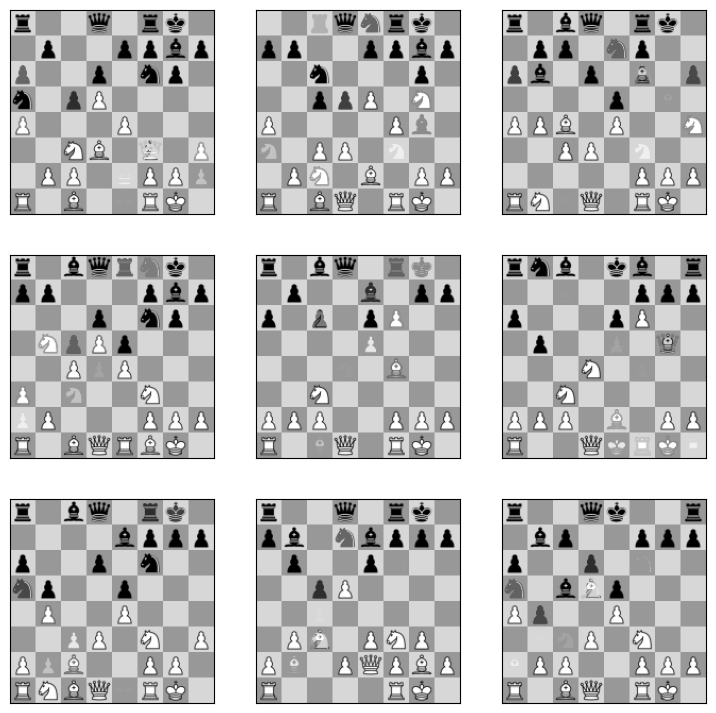

In [41]:
def visualize(anchor, positive, negative):
    """Visualize a few triplets from the supplied batches."""

    def show(ax, image):
        ax.imshow(image)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    fig = plt.figure(figsize=(9, 9))

    axs = fig.subplots(3, 3)
    for i in range(3):
        show(axs[i, 0], anchor[i])
        show(axs[i, 1], positive[i])
        show(axs[i, 2], negative[i])


visualize(*list(train_dataset.take(1).as_numpy_iterator())[0])


In [42]:
from keras.applications import ResNet50
base_cnn = ResNet50(weights="imagenet", input_shape=target_shape+(3,), include_top=False)

from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

flatten = layers.Flatten()(base_cnn.output)
dense1 = layers.Dense(512, activation="relu")(flatten)
dense1 = layers.BatchNormalization()(dense1)
dense2 = layers.Dense(256, activation="relu")(dense1)
dense2 = layers.BatchNormalization()(dense2)
output = layers.Dense(256)(dense2)

embedding = Model(base_cnn.input, output, name="Embedding")

trainable = False
for layer in base_cnn.layers:
    if layer.name == "conv5_block1_out":
        trainable = True
    layer.trainable = trainable

In [43]:
class DistanceLayer(layers.Layer):
    """
    This layer is responsible for computing the distance between the anchor
    embedding and the positive embedding, and the anchor embedding and the
    negative embedding.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, anchor, positive, negative):
        ap_distance = tf.reduce_sum(tf.square(anchor - positive), -1)
        an_distance = tf.reduce_sum(tf.square(anchor - negative), -1)
        return (ap_distance, an_distance)


anchor_input = layers.Input(name="anchor", shape=target_shape + (3,))
positive_input = layers.Input(name="positive", shape=target_shape + (3,))
negative_input = layers.Input(name="negative", shape=target_shape + (3,))

distances = DistanceLayer()(
    embedding(resnet.preprocess_input(anchor_input)),
    embedding(resnet.preprocess_input(positive_input)),
    embedding(resnet.preprocess_input(negative_input)),
)

siamese_network = Model(
    inputs=[anchor_input, positive_input, negative_input], outputs=distances
)

In [44]:
class SiameseModel(Model):
    """The Siamese Network model with a custom training and testing loops.

    Computes the triplet loss using the three embeddings produced by the
    Siamese Network.

    The triplet loss is defined as:
       L(A, P, N) = max(‖f(A) - f(P)‖² - ‖f(A) - f(N)‖² + margin, 0)
    """

    def __init__(self, siamese_network, margin=0.5):
        super().__init__()
        self.siamese_network = siamese_network
        self.margin = margin
        self.loss_tracker = metrics.Mean(name="loss")

    def call(self, inputs):
        return self.siamese_network(inputs)

    def train_step(self, data):
        # GradientTape is a context manager that records every operation that
        # you do inside. We are using it here to compute the loss so we can get
        # the gradients and apply them using the optimizer specified in
        # `compile()`.
        with tf.GradientTape() as tape:
            loss = self._compute_loss(data)

        # Storing the gradients of the loss function with respect to the
        # weights/parameters.
        gradients = tape.gradient(loss, self.siamese_network.trainable_weights)

        # Applying the gradients on the model using the specified optimizer
        self.optimizer.apply_gradients(
            zip(gradients, self.siamese_network.trainable_weights)
        )

        # Let's update and return the training loss metric.
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        loss = self._compute_loss(data)

        # Let's update and return the loss metric.
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def _compute_loss(self, data):
        # The output of the network is a tuple containing the distances
        # between the anchor and the positive example, and the anchor and
        # the negative example.
        ap_distance, an_distance = self.siamese_network(data)

        # Computing the Triplet Loss by subtracting both distances and
        # making sure we don't get a negative value.
        loss = ap_distance - an_distance
        loss = tf.maximum(loss + self.margin, 0.0)
        return loss

    @property
    def metrics(self):
        # We need to list our metrics here so the `reset_states()` can be
        # called automatically.
        return [self.loss_tracker]


## Entrenamiento del Modelo

Ahora entrenamos la red siamesa. El modelo aprenderá a:
- Minimizar la distancia entre partidas del mismo jugador (Olafsson)
- Maximizar la distancia entre partidas de jugadores diferentes

**Nota**: Con solo 13 ejemplos, el modelo puede overfittear. Es un experimento de concepto.

In [45]:
# Crear y compilar el modelo
print("Creando modelo siamés...")
siamese_model = SiameseModel(siamese_network)
siamese_model.compile(optimizer=optimizers.Adam(0.0001))

print("\nIniciando entrenamiento...")
print("Con dataset pequeño, puede tomar varios minutos por epoch.\n")

try:
    history = siamese_model.fit(
        train_dataset, 
        epochs=10, 
        validation_data=val_dataset,
        verbose=1
    )
    print("\n✓ Entrenamiento completado exitosamente")
except Exception as e:
    print(f"\n✗ Error durante el entrenamiento: {e}")
    print("\nPosibles soluciones:")
    print("  1. Reducir batch_size en la celda anterior (de 32 a 16 u 8)")
    print("  2. Reducir epochs (de 10 a 5)")
    print("  3. Añadir más partidas de Olafsson al dataset")
    raise


Creando modelo siamés...

Iniciando entrenamiento...
Con dataset pequeño, puede tomar varios minutos por epoch.

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 68s 27s/step - loss: 0.4669 - val_loss: 0.0465
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0712 - val_loss: 0.0000e+00
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.1141 - val_loss: 0.0000e+00
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0000e+00 - val_

## Evaluación del Modelo

Ahora evaluamos si la red siamesa puede reconocer el estilo de Olafsson comparando distancias:
- La distancia entre dos partidas de Olafsson debería ser **pequeña** (similar)
- La distancia entre Olafsson y otro jugador debería ser **grande** (diferente)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..-102.939].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..-102.939].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..-102.939].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..-102.939].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..-102.939].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..-102.939].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..-102.939].
Clipping inpu


RESULTADOS DE ESTILOMETRÍA

Distancia promedio entre partidas de Olafsson (debería ser BAJA):
  2.5742 ± 0.7437

Distancia promedio entre Olafsson y otros jugadores (debería ser ALTA):
  5.5898 ± 0.4775

Ratio (mayor es mejor): 2.17x


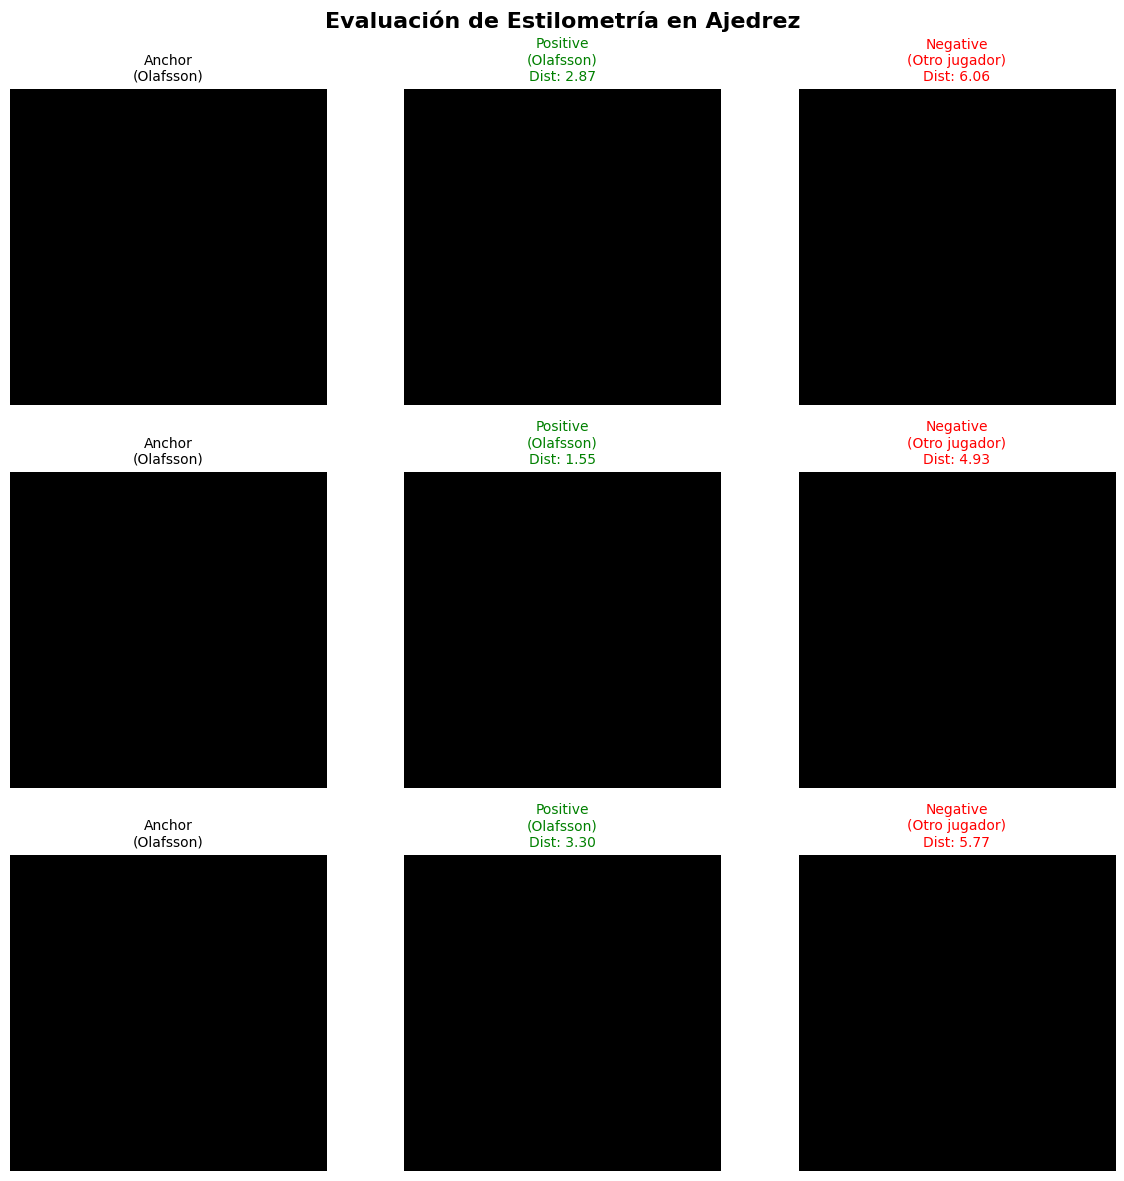

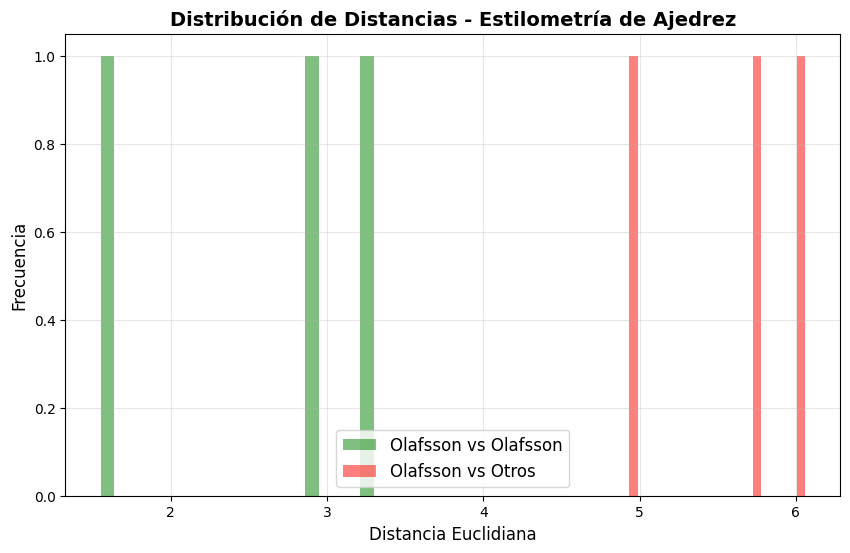

In [46]:
# Evaluar el modelo con embeddings
def compute_distance(embedding1, embedding2):
    """Calcula la distancia euclidiana entre dos embeddings"""
    return np.sum(np.square(embedding1 - embedding2))

# Tomar algunos ejemplos del dataset de validación
sample_batch = list(val_dataset.take(1).as_numpy_iterator())[0]
anchor_imgs, positive_imgs, negative_imgs = sample_batch

# Hacer copias de los arrays para evitar el error de read-only
anchor_imgs = anchor_imgs.copy()
positive_imgs = positive_imgs.copy()
negative_imgs = negative_imgs.copy()

# Obtener embeddings
anchor_embeddings = embedding(resnet.preprocess_input(anchor_imgs))
positive_embeddings = embedding(resnet.preprocess_input(positive_imgs))
negative_embeddings = embedding(resnet.preprocess_input(negative_imgs))

# Calcular distancias
positive_distances = []
negative_distances = []

for i in range(len(anchor_embeddings)):
    pos_dist = compute_distance(anchor_embeddings[i], positive_embeddings[i])
    neg_dist = compute_distance(anchor_embeddings[i], negative_embeddings[i])
    positive_distances.append(pos_dist)
    negative_distances.append(neg_dist)

print("\n" + "="*70)
print("RESULTADOS DE ESTILOMETRÍA")
print("="*70)
print(f"\nDistancia promedio entre partidas de Olafsson (debería ser BAJA):")
print(f"  {np.mean(positive_distances):.4f} ± {np.std(positive_distances):.4f}")
print(f"\nDistancia promedio entre Olafsson y otros jugadores (debería ser ALTA):")
print(f"  {np.mean(negative_distances):.4f} ± {np.std(negative_distances):.4f}")
print(f"\nRatio (mayor es mejor): {np.mean(negative_distances) / np.mean(positive_distances):.2f}x")
print("="*70)

# Visualizar algunos ejemplos
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Evaluación de Estilometría en Ajedrez', fontsize=16, fontweight='bold')

for i in range(min(3, len(anchor_imgs))):
    # Anchor (Olafsson)
    axes[i, 0].imshow(anchor_imgs[i])
    axes[i, 0].set_title(f'Anchor\n(Olafsson)', fontsize=10)
    axes[i, 0].axis('off')
    
    # Positive (Olafsson)
    axes[i, 1].imshow(positive_imgs[i])
    axes[i, 1].set_title(f'Positive\n(Olafsson)\nDist: {positive_distances[i]:.2f}', 
                         fontsize=10, color='green')
    axes[i, 1].axis('off')
    
    # Negative (Otro jugador)
    axes[i, 2].imshow(negative_imgs[i])
    axes[i, 2].set_title(f'Negative\n(Otro jugador)\nDist: {negative_distances[i]:.2f}', 
                         fontsize=10, color='red')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# Histograma de distancias
plt.figure(figsize=(10, 6))
plt.hist(positive_distances, bins=20, alpha=0.5, label='Olafsson vs Olafsson', color='green')
plt.hist(negative_distances, bins=20, alpha=0.5, label='Olafsson vs Otros', color='red')
plt.xlabel('Distancia Euclidiana', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de Distancias - Estilometría de Ajedrez', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

## Interpretación de Resultados

**¿Cómo saber si funciona?**

1. Las distancias entre partidas de Olafsson (verde) deberían ser consistentemente **menores** que las distancias entre Olafsson y otros jugadores (rojo)

2. Un ratio > 1.5x indica que la red está aprendiendo a distinguir el estilo de Olafsson

3. Los histogramas deberían mostrar dos distribuciones separadas, indicando que la red puede diferenciar estilos

**Siguientes pasos:**
- Aumentar epochs si el modelo no converge
- Ajustar el margen en SiameseModel para mejor separación
- Añadir data augmentation para mejorar la generalización
- Probar con más partidas para mejorar la precisión